# Exercitiul 1 - PI


Perform the cross-correlation operation between an input tensor with 3 input channels and the following kernel:

$$
\begin{bmatrix} 0 & 1 \\ 2 & 3 \end{bmatrix}, \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}, \begin{bmatrix} 7 & 2 \\ 3 & 5 \end{bmatrix}.
$$

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

In [ ]:
# 4d tensor with shape 1 x 3 x 3 x 3
x = torch.tensor(
    [
        [
            [
                [1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, 1.0]
            ],
            [
                [1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, 1.0]
            ],
            [
                [1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, 1.0]
            ]
        ]
    ]
)


k = torch.tensor(
    [
        [
            [
                [0.0, 1.0], [2.0, 3.0]
            ],
            [
                [1.0, 2.0], [3.0, 4.0]
            ],
            [
                [7.0, 2.0], [3.0, 5.0]
            ]
        ]
    ]
)

print("X shape is : ", x.shape, "\n")
print("k shape is : ", k.shape, "\n")

F.conv2d(x, k)

X shape is :  torch.Size([1, 3, 3, 3]) 

k shape is :  torch.Size([1, 3, 2, 2]) 



tensor([[[[33., 33.],
          [33., 33.]]]])

# Problema 2 - PI

Classify the SVHN (Street View House Numbers) dataset ($32 \times 32$ images, $10$ classes, $73257$ training images and $26032$ testing images) using the LeNet model. Divide the training dataset as follows: $30000$ validation images and $43257$ training images. Set the learning rate to $0.5$.

In [ ]:
net = nn.Sequential(
    nn.Conv2d(3, 6, kernel_size=5, padding=2), nn.Sigmoid(),  # we have RGB images so 3 instead of 1
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 6 * 6, 120), nn.Sigmoid(),    # dupa ce rulam casuta de mai jos vedem ca in avgpool2d avem 1 x 16 x 6 x 6
    # deci de asta vine 6 in loc de 5
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))
net

Sequential(
  (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): Sigmoid()
  (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): Sigmoid()
  (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=576, out_features=120, bias=True)
  (8): Sigmoid()
  (9): Linear(in_features=120, out_features=84, bias=True)
  (10): Sigmoid()
  (11): Linear(in_features=84, out_features=10, bias=True)
)

In [ ]:
X = torch.randn(1, 3, 32, 32)

for layer in net:
  X = layer(X)
  print(layer.__class__.__name__, " output shape : \t", X.shape)

Conv2d  output shape : 	 torch.Size([1, 6, 32, 32])
Sigmoid  output shape : 	 torch.Size([1, 6, 32, 32])
AvgPool2d  output shape : 	 torch.Size([1, 6, 16, 16])
Conv2d  output shape : 	 torch.Size([1, 16, 12, 12])
Sigmoid  output shape : 	 torch.Size([1, 16, 12, 12])
AvgPool2d  output shape : 	 torch.Size([1, 16, 6, 6])
Flatten  output shape : 	 torch.Size([1, 576])
Linear  output shape : 	 torch.Size([1, 120])
Sigmoid  output shape : 	 torch.Size([1, 120])
Linear  output shape : 	 torch.Size([1, 84])
Sigmoid  output shape : 	 torch.Size([1, 84])
Linear  output shape : 	 torch.Size([1, 10])


In [ ]:
def load_data_SVHN(batch_size, resize=None):
    """Download the SVHN dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    svhn_train = torchvision.datasets.SVHN(
        root="../data", split = 'train', transform=trans, download=True)
    svhn_test = torchvision.datasets.SVHN(
        root="../data", split = 'test', transform=trans, download=True)
    svhn_train, svhn_val = torch.utils.data.random_split(svhn_train, [43257, 30000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(svhn_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [ ]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
batch_size, lr, num_epochs = 256, 0.5, 10
train_iter, val_iter, test_iter = load_data_SVHN(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()) #2 min

Training on cuda:0
Epoch 1, Train loss 2.26, Train accuracy 17.51, Validation loss 2.24, Validation accuracy 18.97
Epoch 2, Train loss 2.24, Train accuracy 18.56, Validation loss 2.24, Validation accuracy 18.97
Epoch 3, Train loss 2.24, Train accuracy 18.73, Validation loss 2.24, Validation accuracy 18.97
Epoch 4, Train loss 2.24, Train accuracy 18.84, Validation loss 2.24, Validation accuracy 18.97
Epoch 5, Train loss 2.24, Train accuracy 18.85, Validation loss 2.24, Validation accuracy 18.97
Epoch 6, Train loss 2.24, Train accuracy 18.88, Validation loss 2.24, Validation accuracy 18.97
Epoch 7, Train loss 2.24, Train accuracy 18.88, Validation loss 2.24, Validation accuracy 18.97
Epoch 8, Train loss 2.24, Train accuracy 18.88, Validation loss 2.24, Validation accuracy 18.97
Epoch 9, Train loss 2.24, Train accuracy 18.88, Validation loss 2.24, Validation accuracy 18.97
Epoch 10, Train loss 2.24, Train accuracy 18.88, Validation loss 2.24, Validation accuracy 18.97
Test loss 2.23, Test

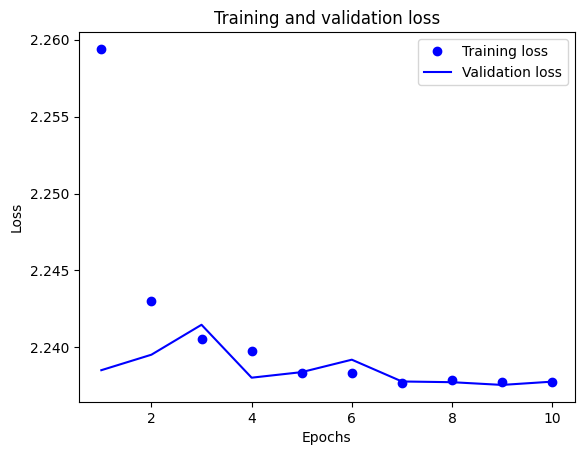

In [ ]:
plot_loss(train_loss_all, val_loss_all)

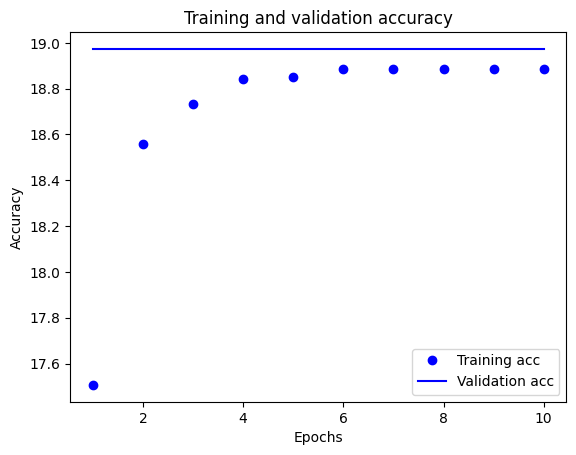

In [ ]:
plot_accuracy(train_acc_all, val_acc_all)

optional

In [ ]:
def get_svhn_labels(labels):
    """Return text labels for the Fashion-MNIST dataset."""
    text_labels = ['0', '1', '2', '3', '4',
                   '5', '6', '7', '8', '9']
    return [text_labels[int(i)] for i in labels]

In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

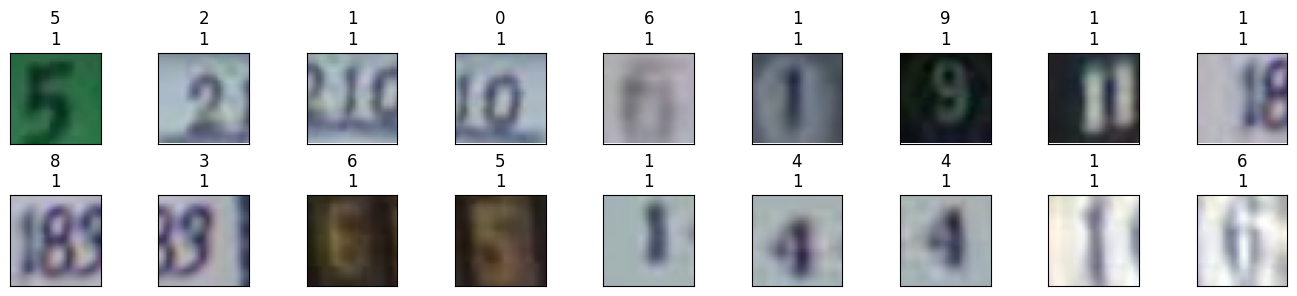

In [ ]:
def predict(net, test_iter, n=18):
    """Predict labels."""
    for X, y in test_iter:
        break
    trues = get_svhn_labels(y)
    preds = get_svhn_labels(net(X.cuda()).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].permute(0,2,3,1), 2, int(n/2), titles=titles[0:n])

predict(net, test_iter)

# Problema 3 - PI

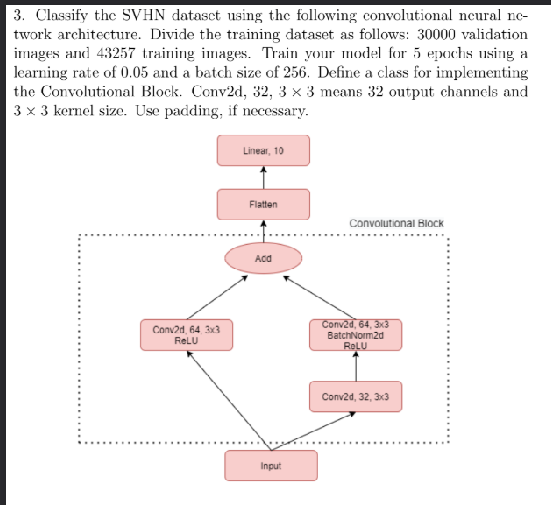

In [ ]:
from torch.nn.modules import padding
class ConvolutionalBlock(nn.Module):
  def __init__(self):
    super().__init__()

    # pe stanga 3 input channels(RGB) , 64 output, 3 x 3 kernel
    self.conv1 = nn.Conv2d(3, 64, kernel_size=3)

    self.relu = nn.ReLU()

    # pe dreapta
    self.conv2 = nn.Conv2d(3, 32, kernel_size=3)

    # pastram dimensiunea
    self.conv3 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)

    self.bn = nn.BatchNorm2d(64)

  def forward(self, X):
    # first branch
    branch1 = nn.ReLU()(self.conv1(X))

    # branch 2
    branch2 = self.conv2(X)

    branch2 = self.conv3(branch2)
    branch2 = self.bn(branch2)
    branch2 = self.relu(branch2)

    return branch1 + branch2

In [ ]:
conv = ConvolutionalBlock()

In [ ]:
net = nn.Sequential(
    conv,
    nn.Flatten(),
    nn.Linear(57600, 10)   # 64 * 30 * 30
)

net

Sequential(
  (0): ConvolutionalBlock(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
    (relu): ReLU()
    (conv2): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=57600, out_features=10, bias=True)
)

In [ ]:
X = torch.randn(1, 3, 32, 32)

for layer in net:
  X = layer(X)
  print(layer.__class__.__name__, " output shape : \t", X.shape)

ConvolutionalBlock  output shape : 	 torch.Size([1, 64, 30, 30])
Flatten  output shape : 	 torch.Size([1, 57600])
Linear  output shape : 	 torch.Size([1, 10])


In [ ]:
def load_data_SVHN(batch_size, resize=None):
    """Download the SVHN dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    svhn_train = torchvision.datasets.SVHN(
        root="../data", split = 'train', transform=trans, download=True)
    svhn_test = torchvision.datasets.SVHN(
        root="../data", split = 'test', transform=trans, download=True)
    svhn_train, svhn_val = torch.utils.data.random_split(svhn_train, [43257, 30000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(svhn_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [ ]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
batch_size, lr, num_epochs = 256, 0.5, 5
train_iter, val_iter, test_iter = load_data_SVHN(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()) #2 min

Training on cuda:0
Epoch 1, Train loss 17.04, Train accuracy 18.16, Validation loss 2.24, Validation accuracy 19.07
Epoch 2, Train loss 2.29, Train accuracy 18.87, Validation loss 2.24, Validation accuracy 19.04
Epoch 3, Train loss 2.24, Train accuracy 18.94, Validation loss 2.24, Validation accuracy 19.04
Epoch 4, Train loss 2.24, Train accuracy 18.92, Validation loss 2.24, Validation accuracy 19.07
Epoch 5, Train loss 2.23, Train accuracy 18.95, Validation loss 2.24, Validation accuracy 19.04
Test loss 2.22, Test accuracy 19.60


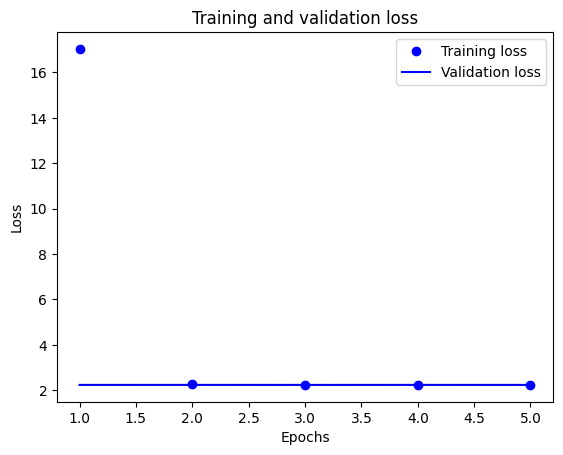

In [ ]:
plot_loss(train_loss_all, val_loss_all)

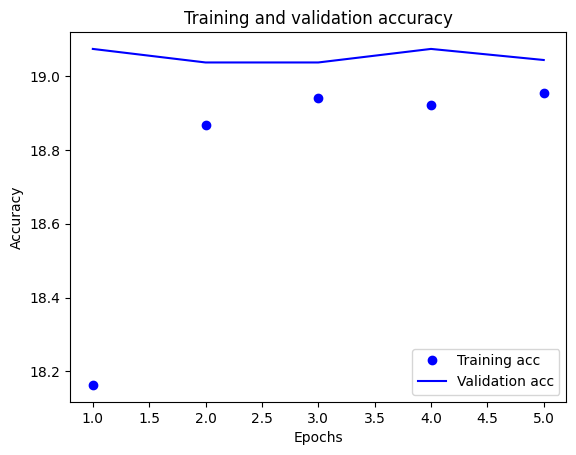

In [ ]:
plot_accuracy(train_acc_all, val_acc_all)

optional

In [ ]:
def get_svhn_labels(labels):
    """Return text labels for the Fashion-MNIST dataset."""
    text_labels = ['0', '1', '2', '3', '4',
                   '5', '6', '7', '8', '9']
    return [text_labels[int(i)] for i in labels]

In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

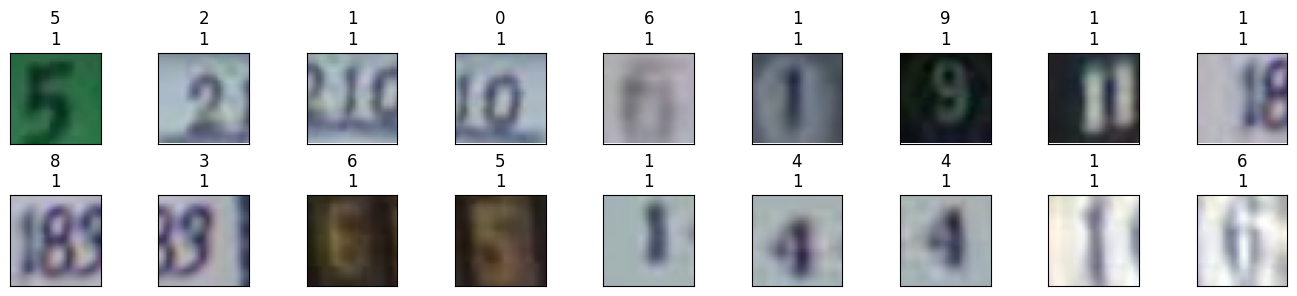

In [ ]:
def predict(net, test_iter, n=18):
    """Predict labels."""
    for X, y in test_iter:
        break
    trues = get_svhn_labels(y)
    preds = get_svhn_labels(net(X.cuda()).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].permute(0,2,3,1), 2, int(n/2), titles=titles[0:n])

predict(net, test_iter)

# Exercitiul 1

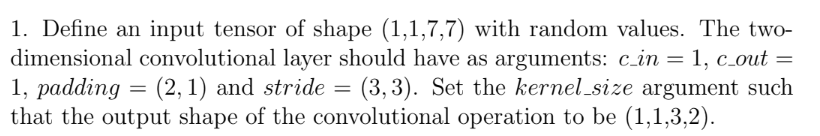

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

In [ ]:
# definim tensorul

input_tensor = torch.randn(1, 1, 7, 7)

print("The input tensor is \n\n", input_tensor, "\n")

# formula este ceil((nh - kh + ph + sh)/sh)
# (7 - kh + 2 * 2 + 3) / 3  = 3 => ceil((14 - kh)/3) = 3   => kh = 3
# ceil((7 - kw + 2 * 1 + 3)/ 3) = 2 => ceil((12 - kw)/3) = 2   => kw = 5

conv_layer = nn.Conv2d(
    in_channels = 1,
    out_channels = 1,
    kernel_size = (3, 5),
    stride = (3, 3),
    padding = (2, 1)
)

print("The conv layer is \n\n", conv_layer, "\n")

output_tensor = conv_layer(input_tensor)

print("The output tensor is \n\n", output_tensor, "\n")
print("The output tensor shape is \n\n", output_tensor.shape, "\n")

The input tensor is 

 tensor([[[[-0.1222, -0.7470,  1.7093,  0.0579,  0.8637, -0.5890, -1.0340],
          [-0.2179,  0.4146,  1.1566,  0.2691, -0.0366, -0.4808,  0.3163],
          [ 0.3866,  0.7337, -0.3136, -0.1293, -0.7150, -0.0476,  0.5230],
          [ 0.9717, -0.2779, -0.6116, -0.0318,  0.1016,  1.3433,  0.7133],
          [ 0.3463, -0.5402,  0.8569, -0.6721,  0.4536,  0.3714, -0.0047],
          [ 0.0795, -0.4560, -0.0619, -0.2222, -1.2470, -0.4862,  0.2659],
          [-0.5871,  0.0827,  0.1858, -0.9698,  1.8932,  0.4447,  0.1364]]]]) 

The conv layer is 

 Conv2d(1, 1, kernel_size=(3, 5), stride=(3, 3), padding=(2, 1)) 

The output tensor is 

 tensor([[[[-0.4112,  0.6609],
          [-0.0867, -0.1940],
          [ 0.0258,  0.2252]]]], grad_fn=<ConvolutionBackward0>) 

The output tensor shape is 

 torch.Size([1, 1, 3, 2]) 



# Exercitiul 2

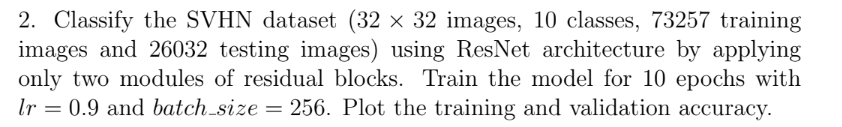

In [ ]:
class Residual(nn.Module):
    """The Residual block of ResNet."""
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(num_channels)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None

    def forward(self, X):
        Y = nn.ReLU()(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return nn.ReLU()(Y)

In [ ]:
def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

In [ ]:
b1 = nn.Sequential(nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),  # rgb image
                   nn.BatchNorm2d(64), nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))

In [ ]:
net = nn.Sequential(b1, b2, b3,
                    nn.AdaptiveAvgPool2d((1, 1)),
                    nn.Flatten(), nn.Linear(128, 10)) # 128 in ultimul sequential
net

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (1): Sequential(
    (0): Residual(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): Residual(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-

In [ ]:
X = torch.randn(1, 3, 32, 32)

for layer in net:
  X = layer(X)
  print(layer.__class__.__name__, " output shape : \t", X.shape)

Sequential  output shape : 	 torch.Size([1, 64, 8, 8])
Sequential  output shape : 	 torch.Size([1, 64, 8, 8])
Sequential  output shape : 	 torch.Size([1, 128, 4, 4])
AdaptiveAvgPool2d  output shape : 	 torch.Size([1, 128, 1, 1])
Flatten  output shape : 	 torch.Size([1, 128])
Linear  output shape : 	 torch.Size([1, 10])


In [ ]:
def load_data_SVHN(batch_size, resize=None):
    """Download the SVHN dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    svhn_train = torchvision.datasets.SVHN(
        root="../data", split = 'train', transform=trans, download=True)
    svhn_test = torchvision.datasets.SVHN(
        root="../data", split = 'test', transform=trans, download=True)
    svhn_train, svhn_val = torch.utils.data.random_split(svhn_train, [43257, 30000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(svhn_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [ ]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
batch_size, lr, num_epochs = 256, 0.9, 10
train_iter, val_iter, test_iter = load_data_SVHN(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()) #2 min

Training on cuda:0


/tmp/ipython-input-2341657111.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss += float(l)


Epoch 1, Train loss 2.44, Train accuracy 18.31, Validation loss 2.24, Validation accuracy 18.94
Epoch 2, Train loss 2.24, Train accuracy 18.76, Validation loss 2.25, Validation accuracy 17.12
Epoch 3, Train loss 1.83, Train accuracy 35.10, Validation loss 2.19, Validation accuracy 34.72
Epoch 4, Train loss 0.78, Train accuracy 74.71, Validation loss 0.67, Validation accuracy 78.39
Epoch 5, Train loss 0.47, Train accuracy 85.12, Validation loss 0.56, Validation accuracy 82.71
Epoch 6, Train loss 0.38, Train accuracy 88.32, Validation loss 0.52, Validation accuracy 83.53
Epoch 7, Train loss 0.31, Train accuracy 90.41, Validation loss 0.45, Validation accuracy 86.73
Epoch 8, Train loss 0.27, Train accuracy 91.69, Validation loss 0.41, Validation accuracy 87.11
Epoch 9, Train loss 0.24, Train accuracy 92.87, Validation loss 0.39, Validation accuracy 88.13
Epoch 10, Train loss 0.21, Train accuracy 93.65, Validation loss 0.38, Validation accuracy 88.31
Test loss 0.39, Test accuracy 88.13


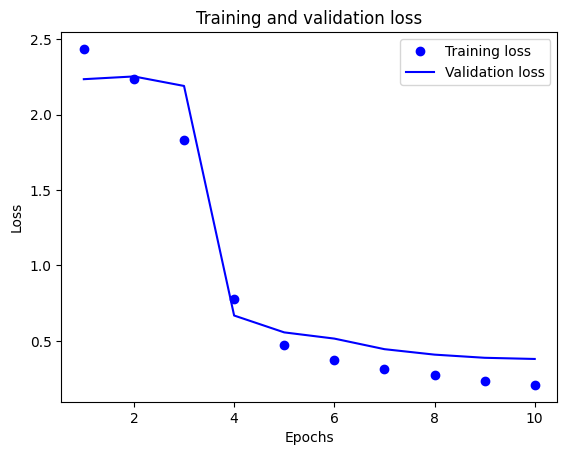

In [ ]:
plot_loss(train_loss_all, val_loss_all)

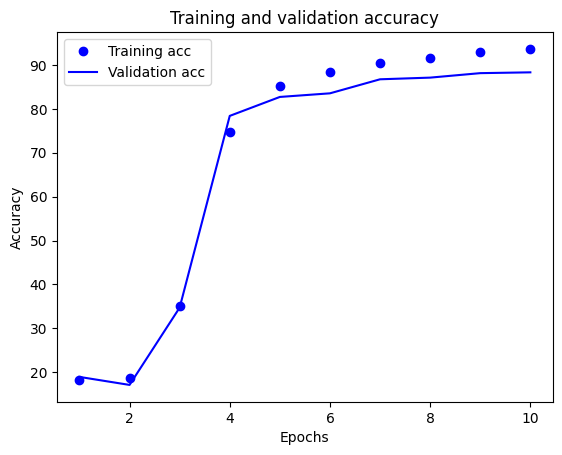

In [ ]:
plot_accuracy(train_acc_all, val_acc_all)

optional

In [ ]:
def get_svhn_labels(labels):
    """Return text labels for the Fashion-MNIST dataset."""
    text_labels = ['0', '1', '2', '3', '4',
                   '5', '6', '7', '8', '9']
    return [text_labels[int(i)] for i in labels]

In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

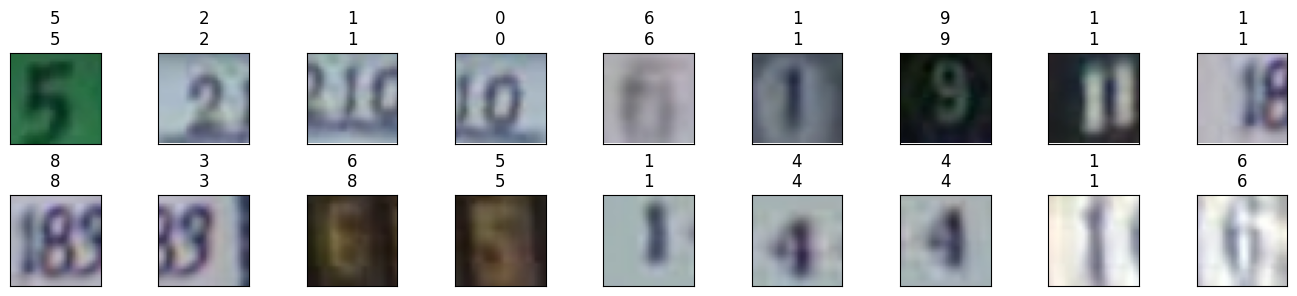

In [ ]:
def predict(net, test_iter, n=18):
    """Predict labels."""
    for X, y in test_iter:
        break
    trues = get_svhn_labels(y)
    preds = get_svhn_labels(net(X.cuda()).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].permute(0,2,3,1), 2, int(n/2), titles=titles[0:n])

predict(net, test_iter)

# Exercitiul 3

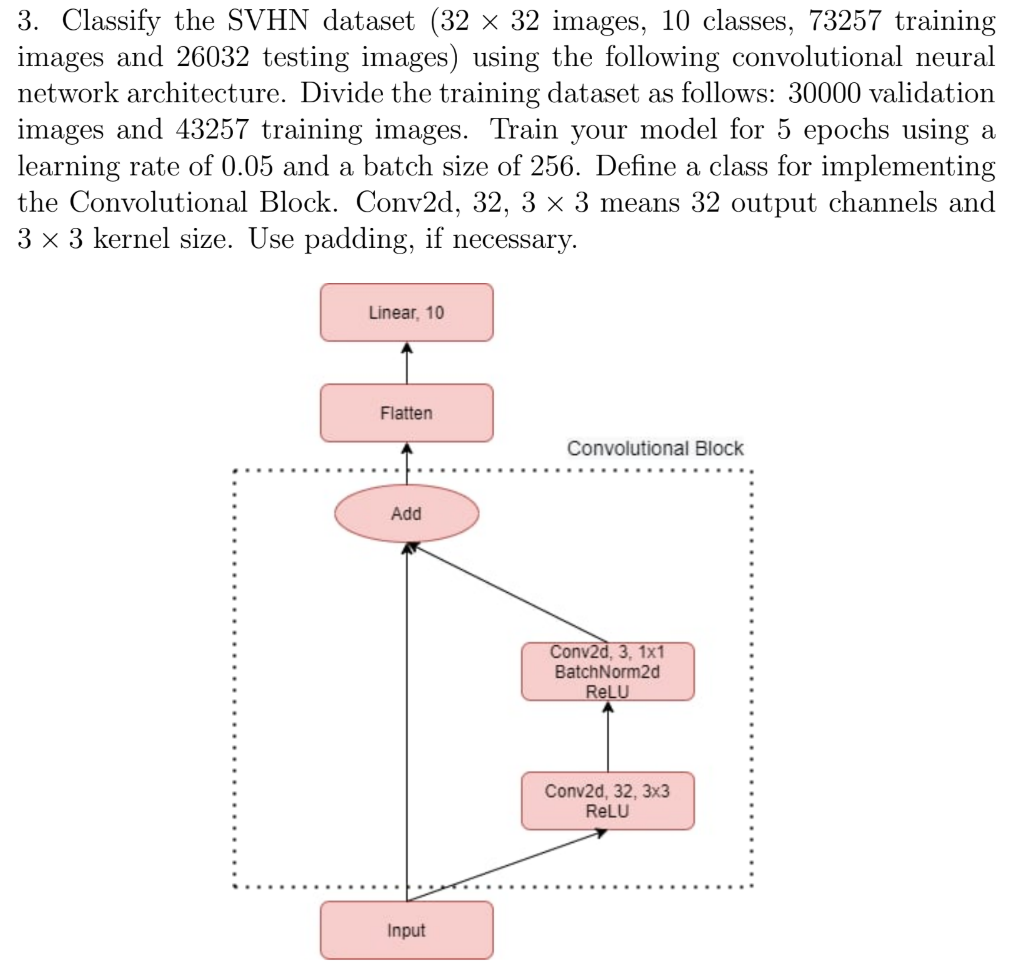

In [ ]:
class ConvolutionalBlock(nn.Module):
  def __init__(self, in_channels):
    super(ConvolutionalBlock, self).__init__()

    # first conv layer de pe dreapta
    # paddigng 1 pt ca
    # n - k + p + s totul pe s
    # n - 3 + p + 1 totul pe 1  => (30 + p) /1 => p = 1  2 * 1 acolo
    self.conv3x3 = nn.Conv2d(in_channels, 32, kernel_size = 3, padding = 1)
    self.relu = nn.ReLU()

    # second one
    self.conv1x1 = nn.Conv2d(32, 3, kernel_size = 1)
    self.bn = nn.BatchNorm2d(3)

  def forward(self, x):
    # branch 1 -> x input

    branch1 = x


    # branch 2 -> input > conv2d > relu > conv2d > batchNorm > relu

    branch2 = self.conv3x3(x)
    branch2 = self.relu(branch2)
    branch2 = self.conv1x1(branch2)
    branch2 = self.bn(branch2)
    branch2 = self.relu(branch2)

    out = branch1 + branch2

    return out

In [ ]:
# modelul complet

net = nn.Sequential(
    ConvolutionalBlock(3),   # 3 input channels rgb image
    nn.Flatten(),
    nn.Linear(3 * 32 * 32, 10)  #-> out channels * height * width si 10 clase
)

net

Sequential(
  (0): ConvolutionalBlock(
    (conv3x3): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (conv1x1): Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))
    (bn): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=3072, out_features=10, bias=True)
)

In [ ]:
X = torch.randn(1, 3, 32, 32)

for layer in net:
  X = layer(X)
  print(layer.__class__.__name__, " output shape : \t", X.shape)

ConvolutionalBlock  output shape : 	 torch.Size([1, 3, 32, 32])
Flatten  output shape : 	 torch.Size([1, 3072])
Linear  output shape : 	 torch.Size([1, 10])


In [ ]:
def load_data_SVHN(batch_size, resize=None):
    """Download the SVHN dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    svhn_train = torchvision.datasets.SVHN(
        root="../data", split = 'train', transform=trans, download=True)
    svhn_test = torchvision.datasets.SVHN(
        root="../data", split = 'test', transform=trans, download=True)
    svhn_train, svhn_val = torch.utils.data.random_split(svhn_train, [43257, 30000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(svhn_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [ ]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
batch_size, lr, num_epochs = 256, 0.05, 5
train_iter, val_iter, test_iter = load_data_SVHN(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()) #2 min

Training on cuda:0
Epoch 1, Train loss 6.28, Train accuracy 12.49, Validation loss 4.88, Validation accuracy 15.89
Epoch 2, Train loss 5.70, Train accuracy 13.46, Validation loss 6.13, Validation accuracy 14.30
Epoch 3, Train loss 5.77, Train accuracy 13.47, Validation loss 5.79, Validation accuracy 20.30
Epoch 4, Train loss 5.53, Train accuracy 13.94, Validation loss 6.24, Validation accuracy 8.05
Epoch 5, Train loss 5.34, Train accuracy 14.39, Validation loss 5.75, Validation accuracy 11.62
Test loss 6.06, Test accuracy 11.06


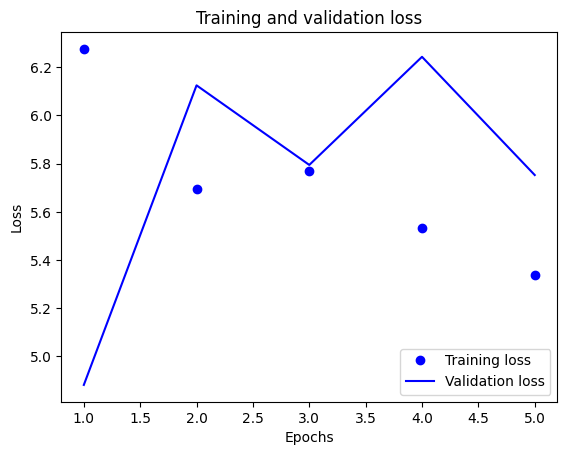

In [ ]:
plot_loss(train_loss_all, val_loss_all)

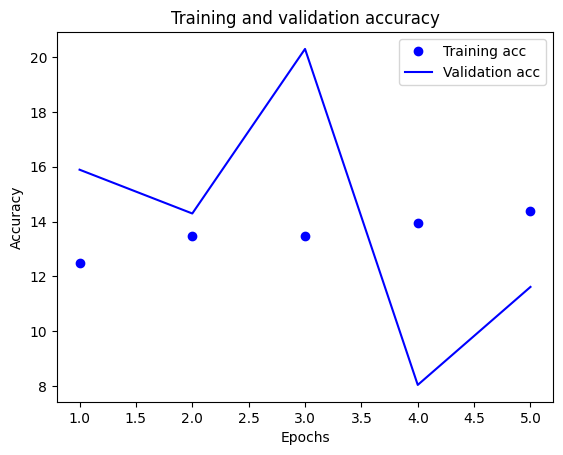

In [ ]:
plot_accuracy(train_acc_all, val_acc_all)

optional

In [ ]:
def get_svhn_labels(labels):
    """Return text labels for the Fashion-MNIST dataset."""
    text_labels = ['0', '1', '2', '3', '4',
                   '5', '6', '7', '8', '9']
    return [text_labels[int(i)] for i in labels]

In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

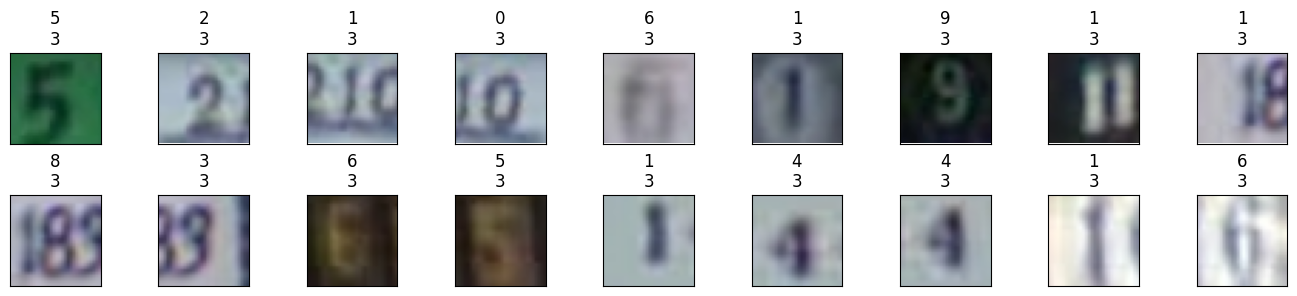

In [ ]:
def predict(net, test_iter, n=18):
    """Predict labels."""
    for X, y in test_iter:
        break
    trues = get_svhn_labels(y)
    preds = get_svhn_labels(net(X.cuda()).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].permute(0,2,3,1), 2, int(n/2), titles=titles[0:n])

predict(net, test_iter)

# Exercitiul 1 - 2

Classify the SVHN dataset ($32 \times 32$ images, $10$ classes, $73\,257$ training images and $26\,032$ testing images) using a convolutional neural network based on depthwise-separable convolutions. Divide the SVHN training set as follows: $43\,257$ training images and $30\,000$ validation images. Use the official test set for final evaluation.

Define a class implementing the Depthwise-Separable Convolutional Block. For an input with $C$ channels, the block must consist of the following sequence:

* Depthwise convolution: `Conv2d(C, C, 3 × 3, padding = 1, groups = C)`
* Pointwise convolution: `Conv2d(C, 2C, 1 × 1)`
* `BatchNorm2d(2C)`
* `ReLU` activation

Design the following network architecture:

(a) An initial convolutional layer: `Conv2d(3, 32, 3 × 3, stride = 1, padding = 1)`, followed by `BatchNorm2d` and `ReLU`.

(b) Four Depthwise-Separable Convolutional Blocks, doubling the number of channels after each block ($32 \rightarrow 64 \rightarrow 128 \rightarrow 256 \rightarrow 512$).

(c) Global average pooling.

(d) A final Linear layer.

Train the model for $10$ epochs using the Adam optimizer with a learning rate of $0.001$ and a batch size of $256$. Use the Cross-Entropy loss function during training.

Produce the following plots:

* Training accuracy vs. validation accuracy
* Training loss vs. validation loss

Finally, compute and report the classification accuracy on the test set.

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

In [ ]:
class DepthwiseSeparableConvBlock(nn.Module):
  def __init__(self, in_channels):
    super().__init__()

    self.depthwise_conv = nn.Conv2d(
        in_channels,
        in_channels,
        kernel_size=3,
        padding=1,
        groups=in_channels
    )

    self.pointwise_conv = nn.Conv2d(
        in_channels,
        2 * in_channels,
        kernel_size = 1
    )

    self.bn = nn.BatchNorm2d(2 * in_channels)

    self.relu = nn.ReLU()

  def forward(self, X):
    branch = self.depthwise_conv(X)
    branch = self.pointwise_conv(branch)
    branch = self.bn(branch)
    branch = self.relu(branch)

    return branch

In [ ]:
class SVHNClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        # a()
        self.initial_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        # b()
        self.ds_block1 = DepthwiseSeparableConvBlock(32)
        self.ds_block2 = DepthwiseSeparableConvBlock(64)
        self.ds_block3 = DepthwiseSeparableConvBlock(128)
        self.ds_block4 = DepthwiseSeparableConvBlock(256)   # ne va scoate 512

        # c()
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # d()
        self.flatten = nn.Flatten()

        self.fc = nn.Linear(512, 10)

    def forward(self, X):
        out = self.initial_layer(X)
        out = self.ds_block1(out)
        out = self.ds_block2(out)
        out = self.ds_block3(out)
        out = self.ds_block4(out)
        out = self.global_avg_pool(out)
        out = self.flatten(out)
        out = self.fc(out)

        return out


In [ ]:
net = SVHNClassifier()

print(net)

SVHNClassifier(
  (initial_layer): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (ds_block1): DepthwiseSeparableConvBlock(
    (depthwise_conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
    (pointwise_conv): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (ds_block2): DepthwiseSeparableConvBlock(
    (depthwise_conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
    (pointwise_conv): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (ds_block3): DepthwiseSeparableConvBlock(
    (depthwise_conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1

In [ ]:
def load_data_SVHN(batch_size, resize=None):
    """Download the SVHN dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    svhn_train = torchvision.datasets.SVHN(
        root="../data", split = 'train', transform=trans, download=True)
    svhn_test = torchvision.datasets.SVHN(
        root="../data", split = 'test', transform=trans, download=True)
    svhn_train, svhn_val = torch.utils.data.random_split(svhn_train, [43257, 30000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(svhn_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train_with_adam(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model with Adam optimizer."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr) # Changed to Adam
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [ ]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
batch_size, lr, num_epochs = 256, 0.001, 10
train_iter, val_iter, test_iter = load_data_SVHN(batch_size)

train_loss_all, train_acc_all, val_loss_all, val_acc_all = train_with_adam(
    net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()
)


Training on cuda:0
Epoch 1, Train loss 1.95, Train accuracy 31.59, Validation loss 1.83, Validation accuracy 36.95
Epoch 2, Train loss 1.43, Train accuracy 53.09, Validation loss 1.41, Validation accuracy 53.74
Epoch 3, Train loss 1.10, Train accuracy 65.70, Validation loss 1.47, Validation accuracy 52.36
Epoch 4, Train loss 0.91, Train accuracy 71.79, Validation loss 3.76, Validation accuracy 29.46
Epoch 5, Train loss 0.78, Train accuracy 76.13, Validation loss 1.22, Validation accuracy 58.38
Epoch 6, Train loss 0.69, Train accuracy 78.77, Validation loss 1.03, Validation accuracy 66.44
Epoch 7, Train loss 0.63, Train accuracy 80.49, Validation loss 1.04, Validation accuracy 67.22
Epoch 8, Train loss 0.59, Train accuracy 81.95, Validation loss 0.84, Validation accuracy 73.04
Epoch 9, Train loss 0.54, Train accuracy 83.54, Validation loss 1.58, Validation accuracy 58.10
Epoch 10, Train loss 0.51, Train accuracy 84.37, Validation loss 0.97, Validation accuracy 70.96
Test loss 0.84, Test

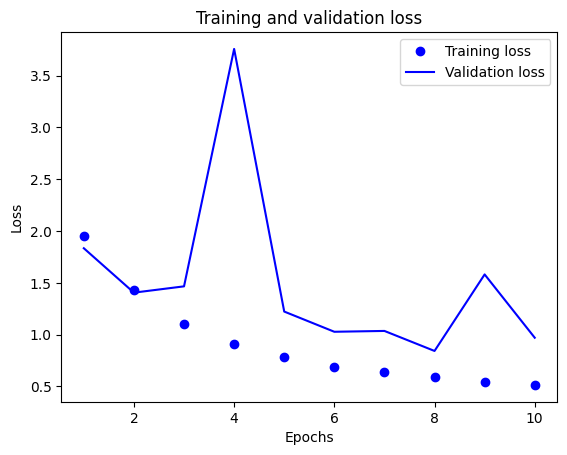

In [ ]:
plot_loss(train_loss_all, val_loss_all)

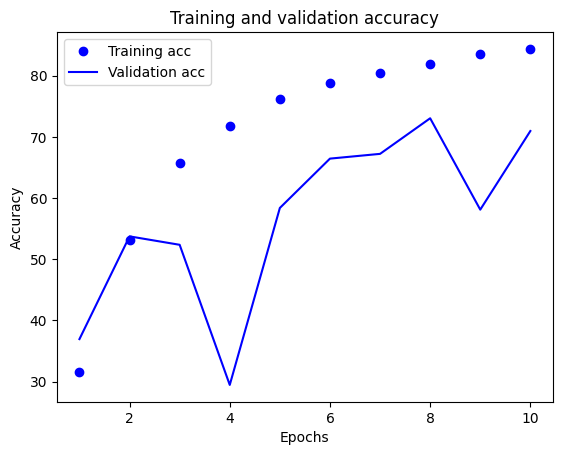

In [ ]:
plot_accuracy(train_acc_all, val_acc_all)

# Problema 2 - 2

Use the `torchsummary` package to print a detailed summary of the model defined at the previous exercise. The summary must compute the output shape after every layer based on an input of size $(3, 224, 224)$ and must include, for every layer:

* the output tensor shape,
* the number of learnable parameters.

Verify that the output shapes reported by `torchsummary` match the expected dimensions computed manually from the architecture.

In [ ]:
!pip install torchsummary

In [ ]:
import torch
from torchsummary import summary
from torch import nn

In [ ]:
model = SVHNClassifier()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [ ]:
print(f"Model summary on {device}:")
summary(model, input_size=(3, 224, 224))

Model summary on cuda:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
              ReLU-3         [-1, 32, 224, 224]               0
            Conv2d-4         [-1, 32, 224, 224]             320
            Conv2d-5         [-1, 64, 224, 224]           2,112
       BatchNorm2d-6         [-1, 64, 224, 224]             128
              ReLU-7         [-1, 64, 224, 224]               0
DepthwiseSeparableConvBlock-8         [-1, 64, 224, 224]               0
            Conv2d-9         [-1, 64, 224, 224]             640
           Conv2d-10        [-1, 128, 224, 224]           8,320
      BatchNorm2d-11        [-1, 128, 224, 224]             256
             ReLU-12        [-1, 128, 224, 224]               0
DepthwiseSeparableConvBlock-13        [-1, 128, 224, 224]              

# Problema 3 - 2

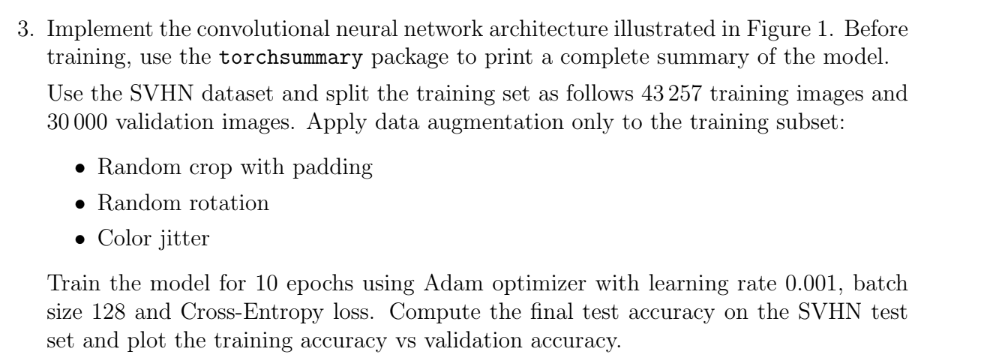

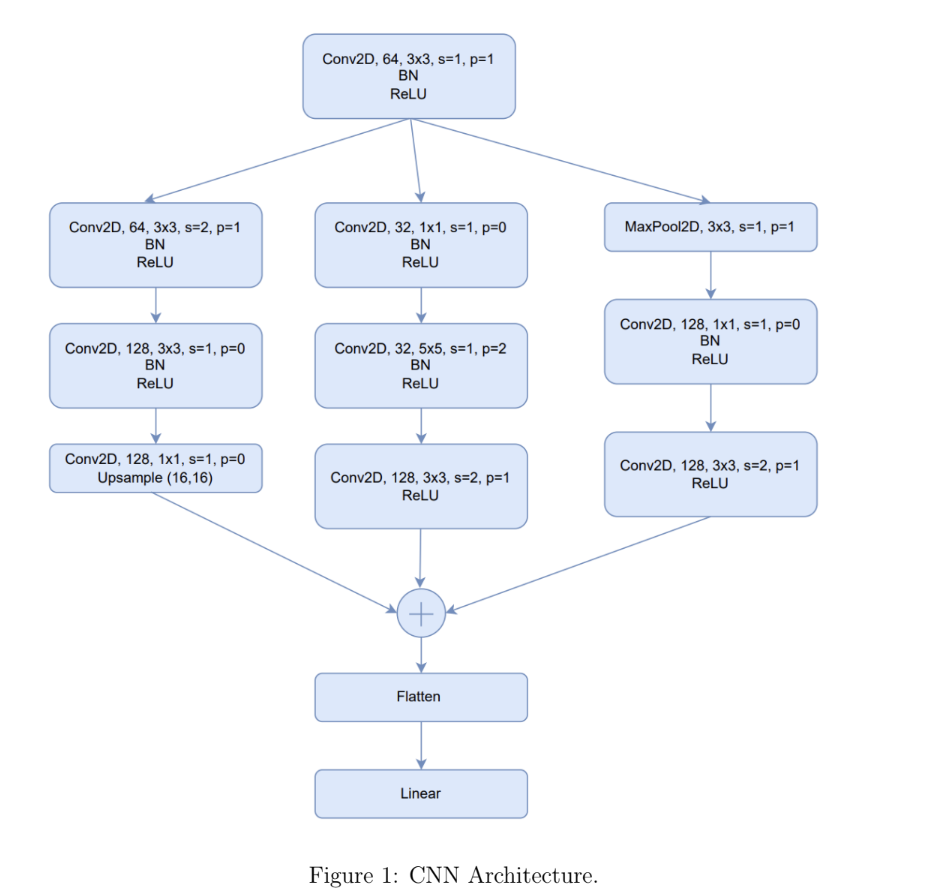

In [ ]:
import torch
from torch import nn
from torchsummary import summary
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

In [ ]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    # top layer
    self.initial_layer = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
    )

    # stanga
    self.branch1 = nn.Sequential(
            # Conv 64, 3x3, s=2, p=1 -> Output: 64 x 16 x 16
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # Conv 128, 3x3, s=1, p=0 -> Output: 128 x 14 x 14 (padding 0 scade dim)
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # Conv 128, 1x1, s=1, p=0 -> Output: 128 x 14 x 14
            nn.Conv2d(128, 128, kernel_size=1, stride=1, padding=0),
            # Upsample (16, 16) -> Revine la 128 x 16 x 16
            nn.Upsample(size=(16, 16), mode='bilinear', align_corners=False)
        )

    # mijloc
    self.branch2 = nn.Sequential(
            # Conv 32, 1x1 -> Output: 32 x 32 x 32
            nn.Conv2d(64, 32, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Conv 32, 5x5, s=1, p=2 -> Output: 32 x 32 x 32
            nn.Conv2d(32, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Conv 128, 3x3, s=2, p=1 -> Output: 128 x 16 x 16
            nn.Conv2d(32, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

    # dreapta
    self.branch3_pool = nn.MaxPool2d(kernel_size=3, stride=1, padding=1) # 32x32

    self.branch3_convs = nn.Sequential(
            # Conv 128, 1x1 -> Output: 128 x 32 x 32
            nn.Conv2d(64, 128, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # Conv 128, 3x3, s=2, p=1 -> Output: 128 x 16 x 16
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )


    # final
    self.flatten = nn.Flatten()

    # Concatenare: 128 + 128 + 128 = 384 canale. Dimensiune 16x16.
    # Linear Input: 384 * 16 * 16 = 98304
    self.fc = nn.Linear(384 * 16 * 16, 10)

  def forward(self, x):
    x = self.initial_layer(x)

    out1 = self.branch1(x)

    out2 = self.branch2(x)

    out3 = self.branch3_pool(x)
    out3 = self.branch3_convs(out3)

    out = torch.cat((out1, out2, out3), dim=1)

    out = self.flatten(out)
    out = self.fc(out)

    return out

In [ ]:
def load_data_SVHN(batch_size, resize=None):
    """Download the SVHN dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)

    svhn_train = torchvision.datasets.SVHN(
        root="../data", split = 'train', transform=trans, download=True)
    svhn_test = torchvision.datasets.SVHN(
        root="../data", split = 'test', transform=trans, download=True)
    svhn_train, svhn_val = torch.utils.data.random_split(svhn_train, [43257, 30000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(svhn_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train_with_adam(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model with Adam optimizer."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr) # Changed to Adam
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [ ]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
device = try_gpu()
model = CNN().to(device)

In [ ]:
print("\n--- Model Summary ---")
summary(model, input_size=(3, 32, 32))


--- Model Summary ---
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 16, 16]          36,928
       BatchNorm2d-5           [-1, 64, 16, 16]             128
              ReLU-6           [-1, 64, 16, 16]               0
            Conv2d-7          [-1, 128, 14, 14]          73,856
       BatchNorm2d-8          [-1, 128, 14, 14]             256
              ReLU-9          [-1, 128, 14, 14]               0
           Conv2d-10          [-1, 128, 14, 14]          16,512
         Upsample-11          [-1, 128, 16, 16]               0
           Conv2d-12           [-1, 32, 32, 32]           2,080
      BatchNorm2d-13           [-1, 32, 32, 32]              64
             ReL

In [ ]:
batch_size, lr, num_epochs = 128, 0.001, 10
train_iter, val_iter, test_iter = load_data_SVHN(batch_size)

train_loss_all, train_acc_all, val_loss_all, val_acc_all = train_with_adam(
    model, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()
)

Training on cuda:0


/tmp/ipython-input-2476538714.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss += float(l)


Epoch 1, Train loss 1.21, Train accuracy 71.21, Validation loss 0.64, Validation accuracy 80.80
Epoch 2, Train loss 0.51, Train accuracy 85.09, Validation loss 0.51, Validation accuracy 85.47
Epoch 3, Train loss 0.43, Train accuracy 87.47, Validation loss 0.54, Validation accuracy 84.25
Epoch 4, Train loss 0.36, Train accuracy 89.16, Validation loss 0.49, Validation accuracy 86.51
Epoch 5, Train loss 0.32, Train accuracy 90.67, Validation loss 0.51, Validation accuracy 86.02
Epoch 6, Train loss 0.29, Train accuracy 91.38, Validation loss 0.54, Validation accuracy 85.77
Epoch 7, Train loss 0.25, Train accuracy 92.27, Validation loss 0.54, Validation accuracy 85.88
Epoch 8, Train loss 0.22, Train accuracy 93.14, Validation loss 0.60, Validation accuracy 85.22
Epoch 9, Train loss 0.20, Train accuracy 93.83, Validation loss 0.60, Validation accuracy 86.09
Epoch 10, Train loss 0.18, Train accuracy 94.26, Validation loss 0.66, Validation accuracy 85.47
Test loss 0.82, Test accuracy 83.05


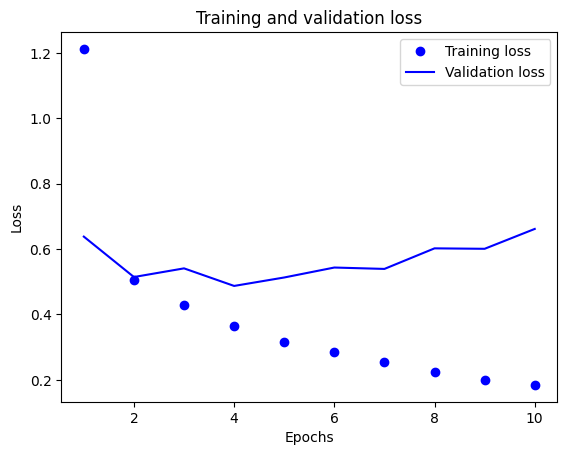

In [ ]:
plot_loss(train_loss_all, val_loss_all)

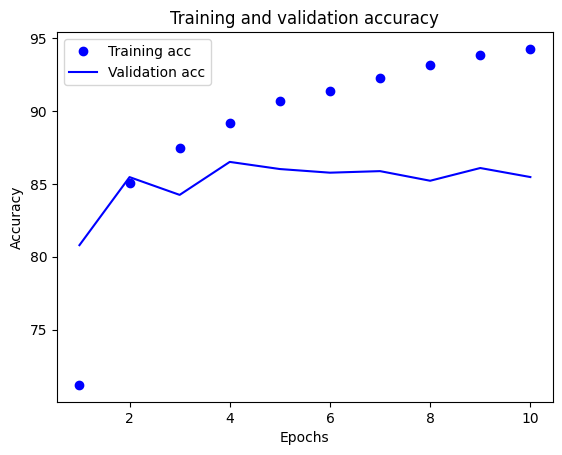

In [ ]:
plot_accuracy(train_acc_all, val_acc_all)